In [16]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.distributions import MultivariateNormal
import seaborn as sns
import scoringrules as sr
sns.set_theme('notebook','white')

In [17]:
def dist(mu,sigma, rho):
    return MultivariateNormal(loc=torch.tensor([mu,mu]), covariance_matrix=sigma**2*torch.tensor([[1,rho],[rho,1]]))

In [18]:
norm  = dist(1.,2.,0.6)

In [19]:
x, y  = norm.rsample((2000,)).T

<Axes: xlabel='None', ylabel='None'>

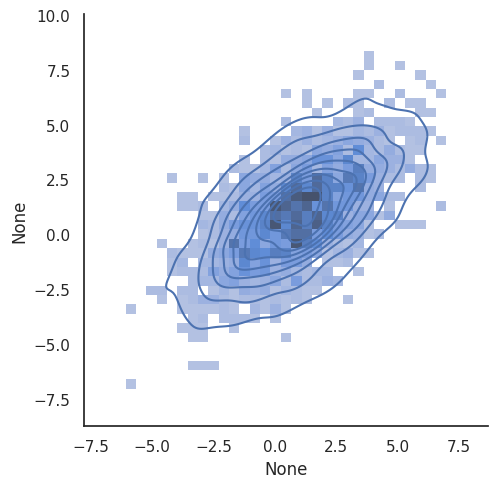

In [20]:
sns.displot(x=x,y=y)
sns.kdeplot(x=x,y=y)

In [21]:
samples = norm.rsample((200,))

In [22]:
fcts = dist(0.,2,0.6).rsample((200,200,))

In [23]:
scores = sr.es_ensemble(samples,fcts)

In [38]:
# error on mu
mu_scores = []
mu_logscores = []
Mu = np.linspace(-2,4,50)
for mu in Mu:
    fcts = dist(np.float32(mu),2.,0.6).rsample((200,200,))
    mu_scores.append(sr.es_ensemble(samples,fcts).mean())
    mu_logscores.append(-np.array(dist(np.float32(mu),2.,0.6).log_prob(samples).mean()))
std_scores = []
std_logscores = []
Std = np.linspace(0.1,5,50)
for std in Std:
    fcts = dist(1.,np.float32(std),0.6).rsample((200,200,))
    std_scores.append(sr.es_ensemble(samples,fcts).mean())
    std_logscores.append(-np.array(dist(np.float32(std),2.,0.6).log_prob(samples).mean()))
rho_scores = []
rho_logscores = []
Rho = np.linspace(-0.95,0.95,50)
for rho in Rho:
    fcts = dist(1.,2.,np.float32(rho)).rsample((200,200,))
    rho_scores.append(sr.es_ensemble(samples,fcts).mean())
    rho_logscores.append(-np.array(dist(np.float32(std),2.,0.6).log_prob(samples).mean()))
    

/tmp/ipykernel_102524/1293412815.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  mu_logscores.append(-np.array(dist(np.float32(mu),2.,0.6).log_prob(samples).mean()))
/tmp/ipykernel_102524/1293412815.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  std_logscores.append(-np.array(dist(np.float32(std),2.,0.6).log_prob(samples).mean()))
/tmp/ipykernel_102524/1293412815.py:22: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=Fal

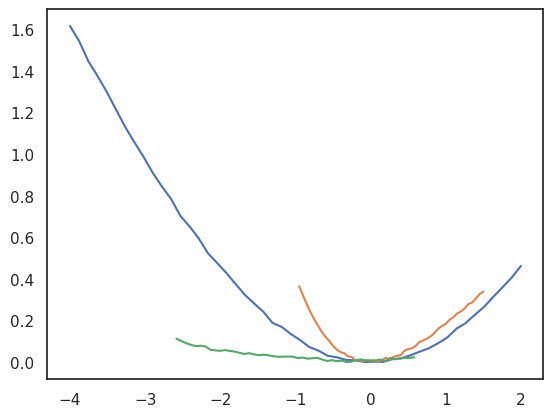

In [25]:
plt.plot(Mu-1,(mu_scores-min(mu_scores)) / min(mu_scores))
plt.plot((Std-2)/2,(std_scores-min(std_scores)) / min(std_scores) )
plt.plot((Rho-0.6)/0.6,(rho_scores-min(rho_scores)) / min(rho_scores))

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import chi2

def plot_gaussian_ellipse(mean, cov, n_std=None, conf=None, ax=None,
                          edgecolor='C0', facecolor='none', linewidth=2, label=None):
    """
    Plot the ellipse of a 2D Gaussian.
    Provide either n_std (Mahalanobis k-sigma) or conf (probability mass, e.g. 0.68).
    """
    mean = np.asarray(mean).ravel()
    cov = np.asarray(cov)

    if mean.shape != (2,) or cov.shape != (2, 2):
        raise ValueError("mean must be length-2 and cov must be 2x2")

    # Convert confidence to n_std (Mahalanobis radius) if needed
    if conf is not None:
        if not (0 < conf < 1):
            raise ValueError("conf must be in (0,1)")
        n_std = np.sqrt(chi2.ppf(conf, df=2))
    elif n_std is None:
        n_std = 1.0  # default to 1-sigma

    # Eigen-decomposition (symmetric matrix)
    vals, vecs = np.linalg.eigh(cov)
    if np.any(vals < 0):
        raise ValueError("covariance must be positive semi-definite")

    # Sort eigenvalues/vectors by descending variance
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    # Ellipse parameters
    width = 2 * n_std * np.sqrt(vals[0])   # major axis length
    height = 2 * n_std * np.sqrt(vals[1])  # minor axis length
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))  # rotation in degrees

    if ax is None:
        fig, ax = plt.subplots()

    ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                  edgecolor=edgecolor, facecolor=facecolor, lw=linewidth, label=label)
    ax.add_patch(ell)
    ax.plot(mean[0], mean[1], 'x', color=edgecolor)  # mark the center

    # Set limits (optional, expand around ellipse)
    pad = 0.2 * max(width, height)
    # ax.set_xlim(mean[0] - width/2 - pad, mean[0] + width/2 + pad)
    # ax.set_ylim(mean[1] - height/2 - pad, mean[1] + height/2 + pad)
    return ax, ell

# Example usage
mu = [1.0, 1.0]
Sigma = 4 * np.array([[1., 0.6],
                  [0.6, 1.0]])

# fig, ax = plt.subplots(1,2, gridspec_kw={'width_ratios': [3, 1]})

# # 1-sigma ellipse (Mahalanobis = 1)
# plot_gaussian_ellipse(mu, Sigma, n_std=1, ax=ax, edgecolor='C0', label='1-sigma (k=1)')

# ax.legend()
# ax.set_title("2D Gaussian Ellipses")
# plt.show()

In [44]:
for i,m in enumerate(Mu):
    fig, ax = plt.subplots(1,2, gridspec_kw={'width_ratios': [1.4, 1]}, figsize = (15,8))
    ax[0].set_xlim(-3.1,3.1)
    ax[0].set_ylim(0,2)
    ax[1].set_ylim(-4,6)
    ax[1].set_xlim(-4,6)
    ax[0].set_xlabel(r'$\hat{\mu} - \mu$')
    ax[0].set_ylabel(r'$\frac{\Delta S_{energy}}{S_{energy}^{ideal}}$')
    ax[0].plot(Mu[:i]-1,(mu_scores[:i]-min(mu_scores)) / min(mu_scores), marker = "v", color = "grey", linestyle = " ")
    ax[0].plot(m-1,(mu_scores[i]-min(mu_scores)) / min(mu_scores), marker = "v", color = "blue")
    plot_gaussian_ellipse([m,m], Sigma, n_std=1, ax=ax[1], edgecolor='blue')
    plot_gaussian_ellipse(mu, Sigma, n_std=1, ax=ax[1], edgecolor='purple')
    plt.savefig(f'./frames_mu/{i}', dpi = 300, transparent = True)
    ax[1].clear()
    plt.clf()

/tmp/ipykernel_102524/1496370840.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1,2, gridspec_kw={'width_ratios': [1.4, 1]}, figsize = (15,8))


<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

...

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

In [45]:
# make_gif.py
# pip install Pillow

from pathlib import Path
from PIL import Image

# ------------------------------------------------------------------
# CONFIG – change these two if you like
FRAMES_DIR = Path("frames_mu")      # where 0.png, 1.png … live
FPS        = 15                # frames per second (gif speed)
OUT_GIF    = "animation_mu.gif"     # output file name
# ------------------------------------------------------------------

# Milliseconds each frame should stay on-screen
duration = round(1000 / FPS)

# Get all *.png, keep numeric order (0.png, 1.png … 199.png)
paths = sorted(FRAMES_DIR.glob("*.png"), key=lambda p: int(p.stem))
if len(paths) == 0:
    raise SystemExit(f"No PNGs found in {FRAMES_DIR}")

# Open first frame (sets size, palette reference)
first = Image.open(paths[0]).convert("RGBA")

# Load the rest, resize if somebody slipped in a different size
others = []
w, h = first.size
for p in paths[1:]:
    img = Image.open(p).convert("RGBA")
    if img.size != (w, h):
        img = img.resize((w, h), Image.LANCZOS)
    others.append(img)



# Write the gif
first.save(
    OUT_GIF,
    save_all=True,
    append_images=others,
    duration=duration,  # ms per frame
    loop=0,             # 0 = loop forever
    disposal=2,         # restore to background between frames (no trails)
    optimize=True,
)

print(f"Saved {OUT_GIF} ({len(paths)} frames, {FPS} fps)")

Saved animation_mu.gif (50 frames, 15 fps)


In [46]:
for i,m in enumerate(Rho):
    fig, ax = plt.subplots(1,2, gridspec_kw={'width_ratios': [1.4, 1]}, figsize = (15,8))
    sigma_r = 4*np.array([[1,m],[m,1]])
    ax[0].set_xlim(-1.7,0.7)
    ax[0].set_ylim(-0.1,0.5)
    ax[1].set_ylim(-4,6)
    ax[1].set_xlim(-4,6)
    ax[0].set_xlabel(r'$\hat{\rho} - \rho$')
    ax[0].set_ylabel(r'$\frac{\Delta S_{energy}}{S_{energy}^{ideal}}$')
    ax[0].plot(Rho[:i] - 0.6, (rho_scores[:i]-min(rho_scores)) / min(rho_scores), marker = "v", color = "grey", linestyle = " ")
    ax[0].plot(m-0.6,(rho_scores[i]-min(rho_scores)) / min(rho_scores), marker = "v", color = "blue")
    plot_gaussian_ellipse(mu, Sigma, n_std=1, ax=ax[1], edgecolor='blue')
    plot_gaussian_ellipse(mu, sigma_r, n_std=1, ax=ax[1], edgecolor='purple')
    plt.savefig(f'./frames_rho/{i}', dpi = 300, transparent = True)
    ax[1].clear()
    plt.clf()

plt.show()

/tmp/ipykernel_102524/1000976143.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1,2, gridspec_kw={'width_ratios': [1.4, 1]}, figsize = (15,8))


<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

...

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

In [47]:
# make_gif.py
# pip install Pillow

from pathlib import Path
from PIL import Image

# ------------------------------------------------------------------
# CONFIG – change these two if you like
FRAMES_DIR = Path("frames_rho")      # where 0.png, 1.png … live
FPS        = 15                # frames per second (gif speed)
OUT_GIF    = "animation_rho.gif"     # output file name
# ------------------------------------------------------------------

# Milliseconds each frame should stay on-screen
duration = round(1000 / FPS)

# Get all *.png, keep numeric order (0.png, 1.png … 199.png)
paths = sorted(FRAMES_DIR.glob("*.png"), key=lambda p: int(p.stem))
if len(paths) == 0:
    raise SystemExit(f"No PNGs found in {FRAMES_DIR}")

# Open first frame (sets size, palette reference)
first = Image.open(paths[0]).convert("RGBA")

# Load the rest, resize if somebody slipped in a different size
others = []
w, h = first.size
for p in paths[1:]:
    img = Image.open(p).convert("RGBA")
    if img.size != (w, h):
        img = img.resize((w, h), Image.LANCZOS)
    others.append(img)



# Write the gif
first.save(
    OUT_GIF,
    save_all=True,
    append_images=others,
    duration=duration,  # ms per frame
    loop=0,             # 0 = loop forever
    disposal=2,         # restore to background between frames (no trails)
    optimize=True,
)

print(f"Saved {OUT_GIF} ({len(paths)} frames, {FPS} fps)")

Saved animation_rho.gif (50 frames, 15 fps)
